In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [5]:
df ['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [16]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'],drop_first=True)

In [17]:
X = df.drop('Exited', axis=1)
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [18]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [20]:
%pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 4.9 MB/s  0:00:38m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 5.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 4.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 5.0 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [tensorflow]4 [tensorflow]]
Note: you may need to restart the kernel to use updated packages.


In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

/Users/nithinys/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [22]:
X_train.shape

(8000, 11)

In [25]:
X_test_trf.shape

(2000, 11)

In [26]:
model = Sequential()
model.add(Dense(5,activation="sigmoid",input_dim=11))
model.add(Dense(10,activation="sigmoid"))
model.add(Dense(1,activation="sigmoid"))

/Users/nithinys/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [31]:
history = model.fit(X_train_trf, y_train, epochs=100, batch_size=50, validation_split=0.2)  

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.8003 - loss: 0.4279 - val_accuracy: 0.7956 - val_loss: 0.4344
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.7975 - loss: 0.4240 - val_accuracy: 0.7956 - val_loss: 0.4343
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.7953 - loss: 0.4273 - val_accuracy: 0.7962 - val_loss: 0.4342
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - accuracy: 0.7891 - loss: 0.4420 - val_accuracy: 0.7962 - val_loss: 0.4341
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - accuracy: 0.7917 - loss: 0.4363 - val_accuracy: 0.7969 - val_loss: 0.4340
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - accuracy: 0.7997 - loss: 0.4278 - val_accuracy: 0.7987 - val_loss: 0.4339
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.7954 - loss: 0.4263 - val_accuracy: 0.7987 - val_loss: 0.4339
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.8013 - loss: 0

In [34]:
model.get_weights()[0]

array([[-0.01151915,  0.42853433, -0.17208481, -0.2671016 ,  0.05271072],
       [ 0.8980856 ,  0.04003562, -1.4289536 ,  1.6096867 ,  0.48617262],
       [ 0.00591445, -0.26448208, -0.22766894, -0.07481203, -0.62195444],
       [-0.13626711, -0.4572908 , -0.50129825,  0.17159809,  0.5423723 ],
       [ 0.09635013, -0.08801502,  0.2828379 , -0.09667358, -0.15982766],
       [-0.2189616 ,  0.48186806,  0.06926172,  0.10100552, -0.05314838],
       [-0.7832552 , -0.45481068, -0.24274796, -0.6603186 , -0.23488621],
       [ 0.32911563,  0.30092144,  0.2699554 , -0.06748896,  0.37585956],
       [ 0.6425172 , -0.3952049 ,  0.07733559,  0.6082353 ,  0.27412766],
       [-0.3842174 , -0.48262316, -0.46146148,  0.00876176,  0.5100116 ],
       [-0.1295923 , -0.07278888,  0.35584572, -0.45006165, -0.432228  ]],
      dtype=float32)

In [35]:
model.get_weights()

[array([[-0.01151915,  0.42853433, -0.17208481, -0.2671016 ,  0.05271072],
        [ 0.8980856 ,  0.04003562, -1.4289536 ,  1.6096867 ,  0.48617262],
        [ 0.00591445, -0.26448208, -0.22766894, -0.07481203, -0.62195444],
        [-0.13626711, -0.4572908 , -0.50129825,  0.17159809,  0.5423723 ],
        [ 0.09635013, -0.08801502,  0.2828379 , -0.09667358, -0.15982766],
        [-0.2189616 ,  0.48186806,  0.06926172,  0.10100552, -0.05314838],
        [-0.7832552 , -0.45481068, -0.24274796, -0.6603186 , -0.23488621],
        [ 0.32911563,  0.30092144,  0.2699554 , -0.06748896,  0.37585956],
        [ 0.6425172 , -0.3952049 ,  0.07733559,  0.6082353 ,  0.27412766],
        [-0.3842174 , -0.48262316, -0.46146148,  0.00876176,  0.5100116 ],
        [-0.1295923 , -0.07278888,  0.35584572, -0.45006165, -0.432228  ]],
       dtype=float32),
 array([-0.22256151, -0.01845821, -0.11206419, -0.43679014, -0.04264619],
       dtype=float32),
 array([[-0.17290503, -0.71320045, -0.03263322, -0.368

In [36]:
model.get_weights()[2].shape

(5, 10)

In [39]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step


In [40]:
y_pred

array([[0.60698646],
       [0.60698646],
       [0.60698646],
       ...,
       [0.60698646],
       [0.42811176],
       [0.6103588 ]], dtype=float32)

In [41]:
y_pred.shape

(2000, 1)

In [43]:
y_pred = y_pred.argmax(axis=-1)

In [44]:
pd.Series(y_pred).value_counts()

0    1
Name: count, dtype: int64

In [50]:
y_pred_prob = model.predict(X_test_trf, verbose=0)

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8115

In [51]:
model.optimizer.get_config()["learning_rate"]

0.009999999776482582

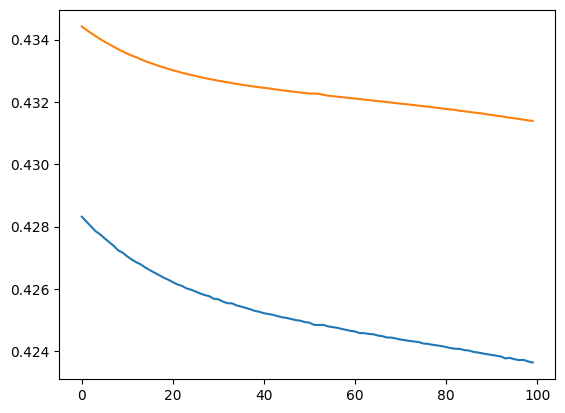

In [52]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

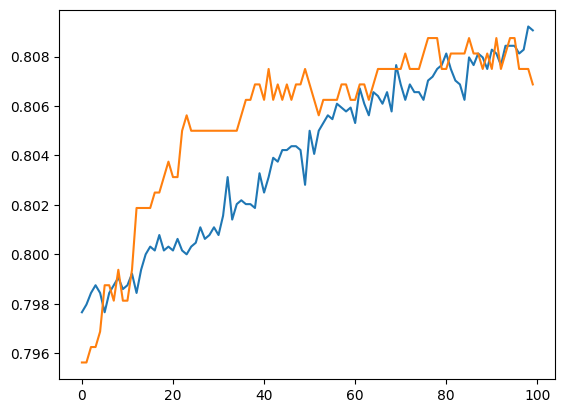

In [53]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [54]:
y_pred = model.predict(X_test)
y_pred_binary = (y_pred >= 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step


In [55]:
y_pred_binary


array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [1]])

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_binary)

0.555

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [58]:
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

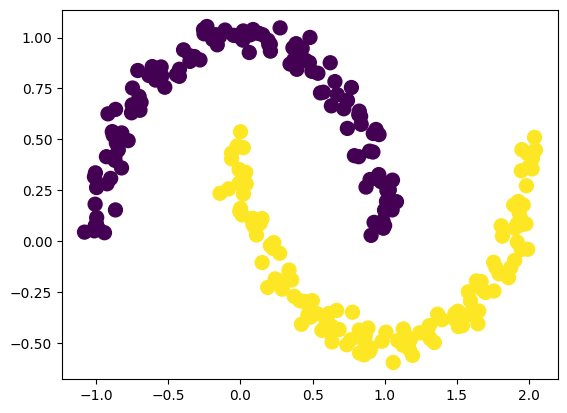

In [59]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [60]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))

model.add(Dense(1, activation='sigmoid'))

/Users/nithinys/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.compile(loss='binary_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [62]:
model.get_weights()[0]

array([[ 0.48846084,  0.6205061 ,  0.6874456 , -0.70615494, -0.05712855,
        -0.15947574,  0.2957124 , -0.70529866, -0.36938053, -0.17531788],
       [-0.6710468 , -0.6631697 ,  0.6071653 ,  0.20540333, -0.4332814 ,
        -0.26057306,  0.4409383 , -0.29879317, -0.3860872 ,  0.21716517]],
      dtype=float32)

In [63]:
old_weights = model.get_weights()[0]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [65]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5072 - loss: 0.7558  
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4855 - loss: 0.7642
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.5013 - loss: 0.7457
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.5340 - loss: 0.7162
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5184 - loss: 0.7173
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5308 - loss: 0.7079
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.5050 - loss: 0.7170
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.5071 - loss: 0.7140
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5085 - loss: 0.7074
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4884 - loss: 0.7131
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.5248 - loss: 0.6974
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - lo

In [66]:
model.optimizer.get_config()["learning_rate"]

0.009999999776482582

In [68]:
new_weights = model.get_weights()[0]

In [69]:
gradient = (old_weights - new_weights)/ model.optimizer.get_config()["learning_rate"]
gradient

array([[-0.34644008,  1.3044298 , -4.9044313 ,  5.876714  , -2.017263  ,
         5.7288156 , -9.809313  , -1.2430549 , -0.4327625 , -0.16567707],
       [ 0.5532801 , -1.026994  ,  4.437411  , -5.980727  ,  1.4942586 ,
        -4.1974473 ,  7.801274  ,  0.99624395,  0.29621124,  0.28146356]],
      dtype=float32)

In [70]:
percent_change = abs(100*(old_weights - new_weights)/ old_weights)
percent_change

array([[ 0.7092484,  2.102203 ,  7.134283 ,  8.322131 , 35.310944 ,
        35.922802 , 33.171795 ,  1.7624518,  1.1715899,  0.9450095],
       [ 0.824503 ,  1.5486143,  7.308407 , 29.116993 ,  3.4487026,
        16.108522 , 17.692438 ,  3.3342261,  0.7672133,  1.2960806]],
      dtype=float32)

In [71]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [72]:
model.compile(loss='binary_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [73]:
old_weights = model.get_weights()[0]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [75]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3328 - loss: 0.6933  
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6222 - loss: 0.6926
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6854 - loss: 0.6927
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6466 - loss: 0.6926
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6607 - loss: 0.6926
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5674 - loss: 0.6926
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5317 - loss: 0.6927
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5325 - loss: 0.6926
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5844 - loss: 0.6925
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5530 - loss: 0.6925
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5802 - loss: 0.6923
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5583 - loss: 0.6924